In [1]:
import matplotlib.pyplot as plt
import csv
import numpy as np

# ═══════════════════════════════════════════════════════════════
#  KNMI Windrose — etmgeg_220.txt
# ═══════════════════════════════════════════════════════════════

# ─── 1. READ DATA ───
filepath = "etmgeg_330.txt"

ddvec_list, fg_list, fxx_list, dates_list = [], [], [], []


with open(filepath, "r") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = [p.strip() for p in line.split(",")]
        if len(parts) < 11:
            continue
        try:
            date = int(parts[1])
            ddvec = int(parts[2]) if parts[2].strip() != "" else np.nan
            fg    = int(parts[4]) if parts[4].strip() != "" else np.nan
            fxx   = int(parts[9]) if parts[9].strip() != "" else np.nan
        except (ValueError, IndexError):
            continue

        dates_list.append(date)
        ddvec_list.append(ddvec)
        fg_list.append(fg)
        fxx_list.append(fxx)

ddvec = np.array(ddvec_list, dtype=float)
fg    = np.array(fg_list, dtype=float) / 10.0   # 0.1 m/s → m/s
fxx   = np.array(fxx_list, dtype=float) / 10.0   # 0.1 m/s → m/s

first_date = str(dates_list[0])
last_date  = str(dates_list[-131])
year_start = first_date[:4]
year_end   = last_date[:4]

print(f"Data: {len(ddvec)} days ({first_date} – {last_date})")

Data: 20219 days (19710101 – 20251231)


In [2]:
# ─── 2.  ───
N_DIR = 16
BIN_WIDTH = 360 / N_DIR  # 22.5°
dir_centers_deg = np.arange(0, 360, BIN_WIDTH)
dir_centers_rad = np.deg2rad(dir_centers_deg)
compass = ['N','NNE','NE','ENE','E','ESE','SE','SSE',
           'S','SSW','SW','WSW','W','WNW','NW','NNW']

def assign_bin(dd):
    """Give winddirection to 16 bins (N-centrated)."""
    adjusted = (dd + BIN_WIDTH / 2) % 360
    bins = (adjusted / BIN_WIDTH).astype(int)
    return np.clip(bins, 0, N_DIR - 1)

def fix_polar_spines(ax):
    for key in ['bottom', 'left', 'right', 'top']:
        if key not in ax.spines:
            ax.spines[key] = ax.spines['polar']



══ Windroos 1: daily mean wind speeds ══
     N:   5.4%
   NNE:   6.8%
    NE:   5.6%
   ENE:   4.5%
     E:   4.8%
   ESE:   3.6%
    SE:   3.2%
   SSE:   3.5%
     S:   6.8%
   SSW:   9.1%
    SW:  12.3%
   WSW:  11.1%
     W:   7.7%
   WNW:   5.6%
    NW:   4.9%
   NNW:   5.1%
  → Highest occurrence: SW (12.3%)
✓ Opgeslagen: windrose_daily_mean.png


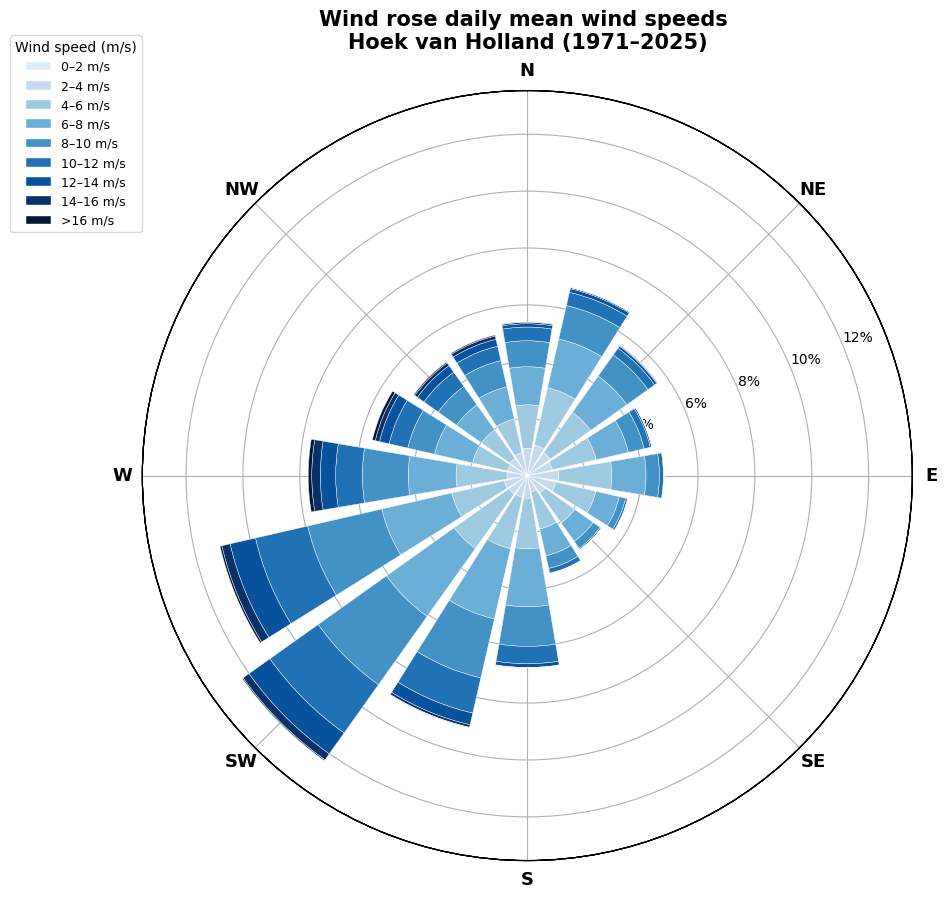

In [3]:

# ═══════════════════════════════════════════════════════════════
#  WIND ROSE 1: Daily mean wind speeds (FG)
# ═══════════════════════════════════════════════════════════════
mask1 = (ddvec > 0) & ~np.isnan(ddvec) & ~np.isnan(fg)
dd1, fg1 = ddvec[mask1], fg[mask1]
bins1 = assign_bin(dd1)
total1 = len(fg1)

speed_edges_1  = [0, 2, 4, 6, 8, 10, 12, 14, 16, 999]
speed_labels_1 = ['0–2','2–4','4–6','6–8','8–10','10–12','12–14','14–16','>16']
colors_1 = ['#deebf7','#c6dbef','#9ecae1','#6baed6','#4292c6',
            '#2171b5','#08519c','#08306b','#041733']

freq1 = np.zeros((N_DIR, len(speed_labels_1)))
for i in range(N_DIR):
    s = fg1[bins1 == i]
    for j in range(len(speed_labels_1)):
        freq1[i, j] = np.sum((s >= speed_edges_1[j]) & (s < speed_edges_1[j+1])) / total1 * 100


dir_totals_1 = freq1.sum(axis=1)
print(f"\n══ Windroos 1: daily mean wind speeds ══")
for i in range(N_DIR):
    print(f"  {compass[i]:>4s}: {dir_totals_1[i]:5.1f}%")
idx1 = np.argmax(dir_totals_1)
print(f"  → Highest occurrence: {compass[idx1]} ({dir_totals_1[idx1]:.1f}%)")

fig1 = plt.figure(figsize=(10, 10))
ax1 = fig1.add_subplot(111, projection='polar')
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(-1)

bw = np.deg2rad(BIN_WIDTH) * 0.85
bottom = np.zeros(N_DIR)
for j in range(len(speed_labels_1)):
    ax1.bar(dir_centers_rad, freq1[:, j], width=bw, bottom=bottom,
            color=colors_1[j], edgecolor='white', linewidth=0.3,
            label=f'{speed_labels_1[j]} m/s', zorder=3)
    bottom += freq1[:, j]


ax1.set_xticks(np.deg2rad([0,45,90,135,180,225,270,315]))
ax1.set_xticklabels(['N','NE','E','SE','S','SW','W','NW'], fontsize=13, fontweight='bold')
ax1.set_ylim(0, bottom.max() * 1.1)
ax1.set_rlabel_position(67.5)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax1.set_title(f'Wind rose daily mean wind speeds \nHoek van Holland ({year_start}–{year_end})',
              fontsize=15, fontweight='bold', pad=30)
ax1.legend(loc='upper left', bbox_to_anchor=(-0.18, 1.08), fontsize=9,
           title='Wind speed (m/s)', title_fontsize=10, frameon=True)

fix_polar_spines(ax1)
fig1.savefig('windrose_daily_mean.png', dpi=200, bbox_inches='tight', facecolor='white')
print("✓ Opgeslagen: windrose_daily_mean.png")



══ Windrose 2: Maximum wind gusts > 30 m/s ══
  Dagen met stoten > 30 m/s: 51 van 20219
     N:   2.0%
   NNE:   0.0%
    NE:   0.0%
   ENE:   0.0%
     E:   0.0%
   ESE:   0.0%
    SE:   0.0%
   SSE:   0.0%
     S:   3.9%
   SSW:   7.8%
    SW:  15.7%
   WSW:  25.5%
     W:  27.5%
   WNW:   5.9%
    NW:   9.8%
   NNW:   2.0%
  → Highest occurrence: W (27.5%)
✓ Opgeslagen: windrose_gusts_30.png


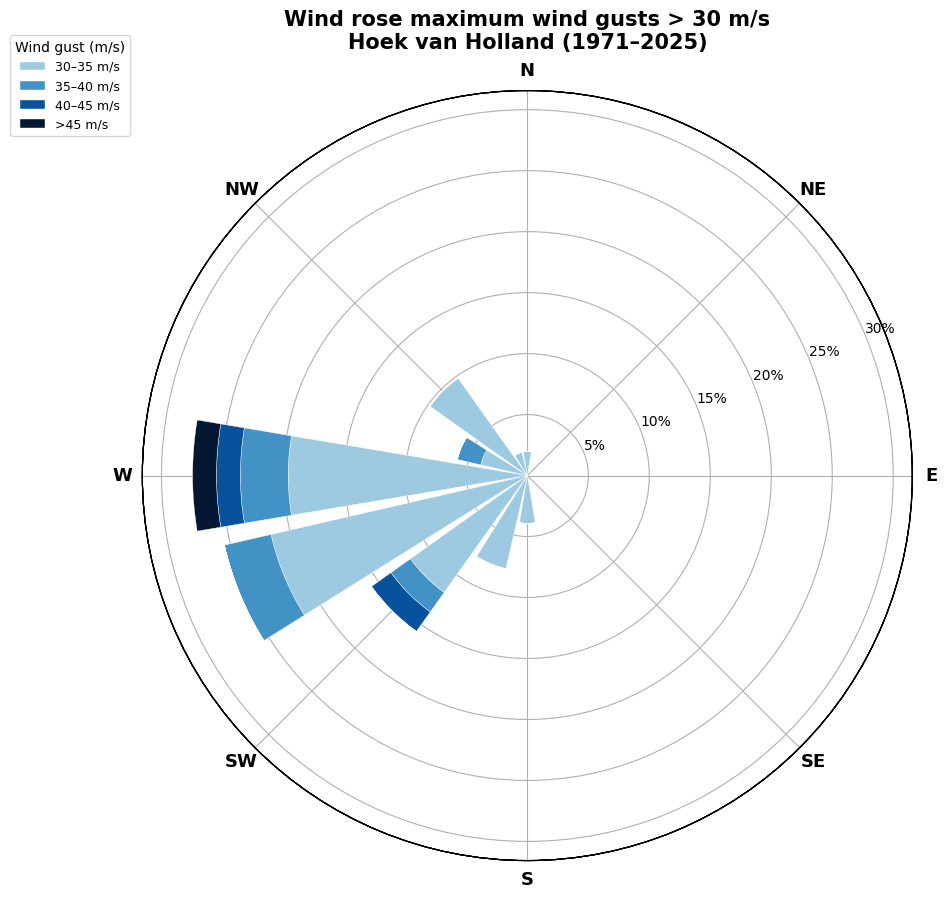

In [4]:

# ═══════════════════════════════════════════════════════════════
#  WINDROSE 2: Maximum wind gusts > 30 m/s
# ═══════════════════════════════════════════════════════════════
mask2 = (ddvec > 0) & ~np.isnan(ddvec) & ~np.isnan(fxx) & (fxx > 30)
dd2, fxx2 = ddvec[mask2], fxx[mask2]
bins2 = assign_bin(dd2)
total2 = len(fxx2)

speed_edges_2  = [30, 35, 40, 45, 999]
speed_labels_2 = ['30–35','35–40','40–45','>45']
colors_2 = ['#9ecae1','#4292c6','#08519c','#041733']

freq2 = np.zeros((N_DIR, len(speed_labels_2)))
for i in range(N_DIR):
    s = fxx2[bins2 == i]
    for j in range(len(speed_labels_2)):
        freq2[i, j] = np.sum((s >= speed_edges_2[j]) & (s < speed_edges_2[j+1])) / total2 * 100


dir_totals_2 = freq2.sum(axis=1)
print(f"\n══ Windrose 2: Maximum wind gusts > 30 m/s ══")
print(f"  Dagen met stoten > 30 m/s: {total2} van {len(ddvec)}")
for i in range(N_DIR):
    print(f"  {compass[i]:>4s}: {dir_totals_2[i]:5.1f}%")
idx2 = np.argmax(dir_totals_2)
print(f"  → Highest occurrence: {compass[idx2]} ({dir_totals_2[idx2]:.1f}%)")

fig2 = plt.figure(figsize=(10, 10))
ax2 = fig2.add_subplot(111, projection='polar')
ax2.set_theta_zero_location('N')
ax2.set_theta_direction(-1)

bottom2 = np.zeros(N_DIR)
for j in range(len(speed_labels_2)):
    ax2.bar(dir_centers_rad, freq2[:, j], width=bw, bottom=bottom2,
            color=colors_2[j], edgecolor='white', linewidth=0.3,
            label=f'{speed_labels_2[j]} m/s', zorder=3)
    bottom2 += freq2[:, j]


ax2.set_xticks(np.deg2rad([0,45,90,135,180,225,270,315]))
ax2.set_xticklabels(['N','NE','E','SE','S','SW','W','NW'], fontsize=13, fontweight='bold')
ax2.set_ylim(0, bottom2.max() * 1.15)
ax2.set_rlabel_position(67.5)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax2.set_title(f'Wind rose maximum wind gusts > 30 m/s\nHoek van Holland ({year_start}–{year_end})',
              fontsize=15, fontweight='bold', pad=30)
ax2.legend(loc='upper left', bbox_to_anchor=(-0.18, 1.08), fontsize=9,
           title='Wind gust (m/s)', title_fontsize=10, frameon=True)

fix_polar_spines(ax2)
fig2.savefig('windrose_gusts_30.png', dpi=200, bbox_inches='tight', facecolor='white')
print("✓ Opgeslagen: windrose_gusts_30.png")

plt.show()



═══ 3-Parameter Weibull fits — Wind gusts (FXX) ═══
Richting  α (shape)  β (scale)    γ (loc)       N
──────────────────────────────────────────────────
       N       1.85       9.32       4.52     828
     NNE       2.24       9.28       3.87    1042
      NE       1.93       7.55       5.43     893
     ENE       2.11       8.14       4.45     698
       E       1.94       7.10       4.81     735
     ESE       1.93       6.99       4.46     588
      SE       2.09       7.35       4.33     501
     SSE       2.14       8.46       4.56     561
       S       2.29      10.44       4.39    1069
     SSW       2.54      12.62       4.00    1465
      SW       2.82      14.32       3.46    1945
     WSW       2.27      12.24       5.30    1748
       W       1.81      11.05       5.56    1207
     WNW       2.06      12.17       3.97     880
      NW       2.04      11.92       3.84     779
     NNW       1.84      10.78       4.27     786

✓ Opgeslagen: return_period_NW.png

══ Refere

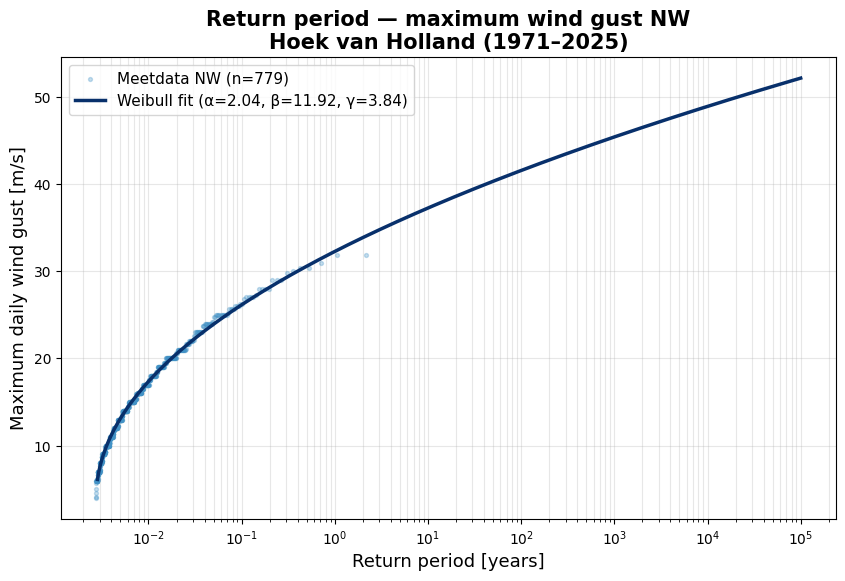

In [13]:
from scipy.stats import weibull_min
from scipy.optimize import curve_fit
import warnings
warnings.filterwarnings("ignore")

# ═══════════════════════════════════════════════════════════════
#  WEIBULL FIT & RETURN PERIOD — WIND GUSTS (FXX)
# ═══════════════════════════════════════════════════════════════

def weibull_return_speed(T_years, alpha, beta, gamma):
    """Calculate wind gusts [m/s] for return period T [jaar]."""
    return gamma + beta * (np.log(365.25 * T_years)) ** (1.0 / alpha)

# ─── Data selection ───
mask_w = (ddvec > 0) & ~np.isnan(ddvec) & ~np.isnan(fxx) & (fxx > 0)
dd_w   = ddvec[mask_w]
fxx_w  = fxx[mask_w]
bins_w = assign_bin(dd_w)

# ─── Weibull fit per direction ───
weibull_params = {}

print("\n═══ 3-Parameter Weibull fits — Wind gusts (FXX) ═══")
print(f"{'Richting':>8s} {'α (shape)':>10s} {'β (scale)':>10s} {'γ (loc)':>10s} {'N':>7s}")
print("─" * 50)


for i in range(N_DIR):
    data_i = fxx_w[bins_w == i]
    data_i = data_i[~np.isnan(data_i)]  # extra NaN-filter
    if len(data_i) < 30:
        print(f"{compass[i]:>8s}  — insufficient data (n={len(data_i)})")
        continue
    try:
        c, loc, scale = weibull_min.fit(data_i)
        weibull_params[compass[i]] = {
            "alpha": c, "beta": scale, "gamma": loc, "n": len(data_i)
        }
        print(f"{compass[i]:>8s} {c:10.2f} {scale:10.2f} {loc:10.2f} {len(data_i):7d}")
    except Exception as e:
        print(f"{compass[i]:>8s}  — fit mislukt: {e}")

# ═══════════════════════════════════════════════════════════════
#  PLOT 3: Return period — NW 
# ═══════════════════════════════════════════════════════════════
target_dir = "NW"

if target_dir in weibull_params:
    p = weibull_params[target_dir]
    alpha, beta, gamma = p["alpha"], p["beta"], p["gamma"]

    data_target = np.sort(fxx_w[bins_w == compass.index(target_dir)])[::-1]
    n_target = len(data_target)
    rank = np.arange(1, n_target + 1)
    T_emp_years = (n_target + 1) / rank / 365.25

    T_th = np.logspace(np.log10(1 / 365.25), np.log10(100000), 500)
    v_th = weibull_return_speed(T_th, alpha, beta, gamma)

    fig3, ax3 = plt.subplots(figsize=(10, 6))
    ax3.scatter(T_emp_years, data_target, s=8, alpha=0.3, color='#4292c6',
                label=f'Meetdata {target_dir} (n={n_target})', zorder=3)
    ax3.plot(T_th, v_th, color='#08306b', linewidth=2.5,
             label=f'Weibull fit (α={alpha:.2f}, β={beta:.2f}, γ={gamma:.2f})',
             zorder=4)

    ax3.set_xscale('log')
    ax3.set_xlabel('Return period [years]', fontsize=13)
    ax3.set_ylabel('Maximum daily wind gust [m/s]', fontsize=13)
    ax3.set_title(f'Return period — maximum wind gust {target_dir}\n'
                  f'Hoek van Holland ({year_start}–{year_end})',
                  fontsize=15, fontweight='bold')
    ax3.legend(fontsize=11)
    ax3.grid(True, which='both', alpha=0.3)

    fig3.savefig(f'return_period_{target_dir}.png', dpi=200,
                 bbox_inches='tight', facecolor='white')
    print(f"\n✓ Opgeslagen: return_period_{target_dir}.png")

    print(f"\n══ Reference values {target_dir} ══")
    for T in [1, 5, 10, 25, 50, 100, 500, 1000, 10000, 100000]:
        v = weibull_return_speed(T, alpha, beta, gamma)
        print(f"  T = {T:>6,d} year  →  v = {v:.1f} m/s")



In [7]:
# # ═══════════════════════════════════════════════════════════════
# #  PLOT 4: Return period — meerdere richtingen
# # ═══════════════════════════════════════════════════════════════
# highlight_dirs = ['NW', 'WNW', 'W', 'WSW', 'SW', 'SSW', 'S']
# dir_colors = {
#     'NW':  '#08306b', 'WNW': '#2171b5', 'W':   '#4292c6',
#     'WSW': '#e41a1c', 'SW':  '#ff7f00', 'SSW': '#984ea3',
#     'S':   '#4daf4a'
# }

# T_th = np.logspace(np.log10(1 / 365.25), np.log10(10000), 500)

# fig4, ax4 = plt.subplots(figsize=(12, 7))
# for d in highlight_dirs:
#     if d not in weibull_params:
#         continue
#     p = weibull_params[d]
#     v_th = weibull_return_speed(T_th, p["alpha"], p["beta"], p["gamma"])
#     ax4.plot(T_th, v_th, linewidth=2, color=dir_colors.get(d, '#333'),
#              label=f'{d}  (α={p["alpha"]:.2f}, β={p["beta"]:.2f}, γ={p["gamma"]:.2f})')

# ax4.set_xscale('log')
# ax4.set_xlabel('Return period [years]', fontsize=13)
# ax4.set_ylabel('Maximum daily wind gust [m/s]', fontsize=13)
# ax4.set_title(f'Return period — maximum wind gust per direction\n'
#               f'Hoek van Holland ({year_start}–{year_end})',
#               fontsize=15, fontweight='bold')
# ax4.legend(fontsize=10, loc='upper left')
# ax4.grid(True, which='both', alpha=0.3)

# fig4.savefig('return_period_all_dirs.png', dpi=200,
#              bbox_inches='tight', facecolor='white')
# print(f"✓ Opgeslagen: return_period_all_dirs.png")

# # ═══════════════════════════════════════════════════════════════
# #  PLOT 5: Weibull PDF vs histogram — NW


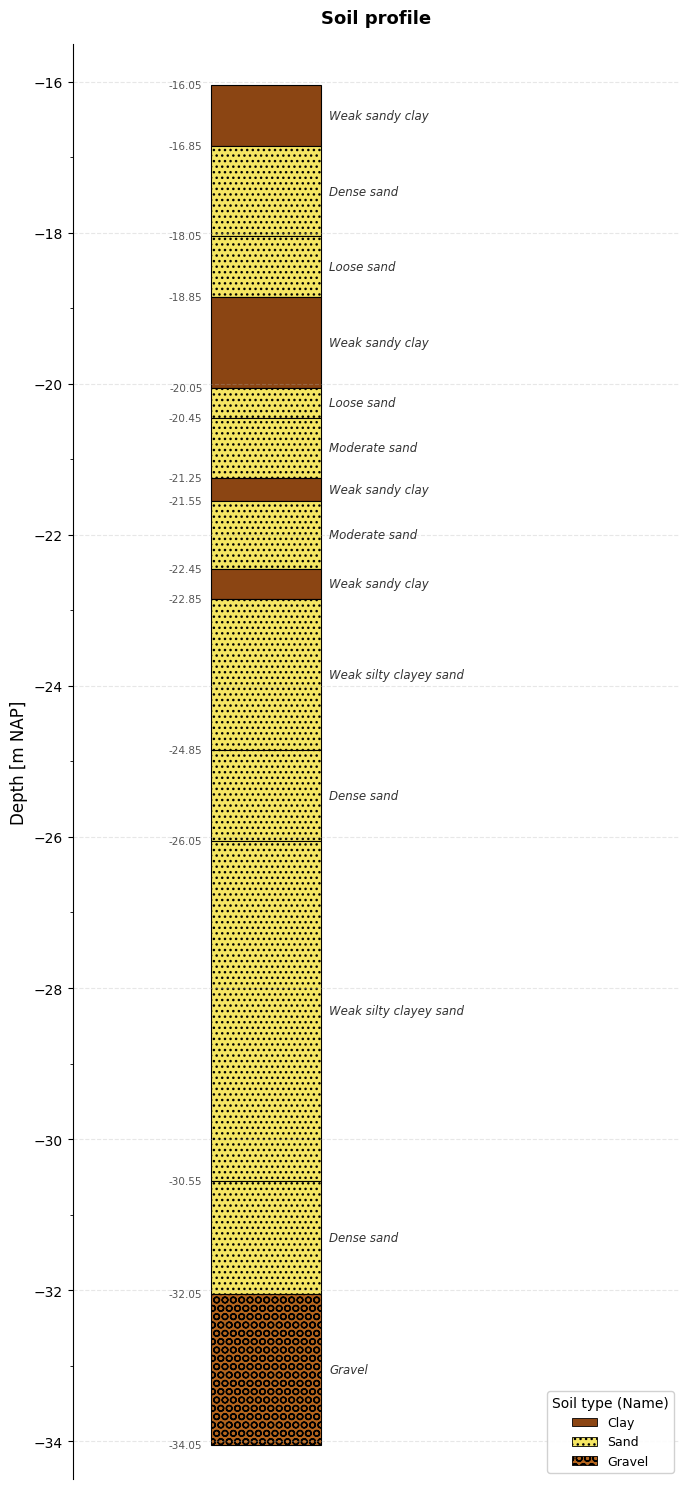

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

layers = [
    (-16.05, -16.85, "Clay",    "Weak sandy"),
    (-16.85, -18.05, "Sand",    "Dense"),
    (-18.05, -18.85, "Sand",    "Loose"),
    (-18.85, -20.05, "Clay",    "Weak sandy"),
    (-20.05, -20.45, "Sand",    "Loose"),
    (-20.45, -21.25, "Sand",    "Moderate"),
    (-21.25, -21.55, "Clay",    "Weak sandy"),
    (-21.55, -22.45, "Sand",    "Moderate"),
    (-22.45, -22.85, "Clay",    "Weak sandy"),
    (-22.85, -24.85, "Sand",    "Weak silty clayey"),
    (-24.85, -26.05, "Sand",    "Dense"),
    (-26.05, -30.55, "Sand",    "Weak silty clayey"),
    (-30.55, -32.05, "Sand",    "Dense"),
    (-32.05, -34.05, "Gravel",  ""),
]

def make_label(name, desc):
    return f"{desc} {name.lower()}" if desc else name

color_map = {"Clay": "#8B4513", "Sand": "#f5e663", "Gravel": "#b5651d"}
hatch_map = {"Clay": "", "Sand": "...", "Gravel": "OO"}

fig, ax = plt.subplots(figsize=(7, 15))
bar_width = 2.0

for top, bottom, name, desc in layers:
    thickness = abs(bottom - top)
    ax.add_patch(mpatches.FancyBboxPatch(
        (-bar_width/2, bottom), bar_width, thickness,
        boxstyle="square,pad=0", facecolor=color_map[name],
        edgecolor="black", linewidth=0.8, hatch=hatch_map[name]))
    ax.text(bar_width/2 + 0.15, bottom + thickness/2,
            make_label(name, desc), fontsize=8.5, va="center",
            ha="left", fontstyle="italic", color="#333333")
    ax.text(-bar_width/2 - 0.15, top, f"{top:.2f}",
            fontsize=7.5, va="center", ha="right", color="#555555")

ax.text(-bar_width/2 - 0.15, layers[-1][1], f"{layers[-1][1]:.2f}",
        fontsize=7.5, va="center", ha="right", color="#555555")

ax.set_ylim(-34.5, -15.5)
ax.set_xlim(-3.5, 7.5)
ax.set_ylabel("Depth [m NAP]", fontsize=12)
ax.set_title("Soil profile",
             fontsize=13, fontweight="bold", pad=15)
ax.set_xticks([])
ax.spines["bottom"].set_visible(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_locator(plt.MultipleLocator(2))
ax.yaxis.set_minor_locator(plt.MultipleLocator(1))
ax.grid(axis="y", alpha=0.3, linestyle="--")

legend_order = ["Clay", "Sand", "Gravel"]
ax.legend(handles=[mpatches.Patch(
    facecolor=color_map[n], edgecolor="black", linewidth=0.6,
    hatch=hatch_map[n], label=n) for n in legend_order],
    loc="lower right", fontsize=9, frameon=True, framealpha=0.9,
    edgecolor="#cccccc", title="Soil type (Name)", title_fontsize=10)

plt.tight_layout()
fig.savefig("soil_profile.png", dpi=200,
            bbox_inches="tight", facecolor="white")
plt.show()

**Tidal Signal**

In [ ]:
import numpy as np

# ═══════════════════════════════════════════════════════════════
#  STEP 1: INPUT
# ═══════════════════════════════════════════════════════════════

MHWS = +1.32   # Mean High Water Spring [m NAP]
MLWS = -0.63   # Mean Low Water Spring  [m NAP]
MHWN = +0.90   # Mean High Water Neap   [m NAP]
MLWN = -0.55   # Mean Low Water Neap    [m NAP]

print(f"\n── STEP 1: Input ──")
print(f"  MHWS = {MHWS:+.2f} m NAP")
print(f"  MLWS = {MLWS:+.2f} m NAP")
print(f"  MHWN = {MHWN:+.2f} m NAP")
print(f"  MLWN = {MLWN:+.2f} m NAP")

# ═══════════════════════════════════════════════════════════════
#  STEP 2: Tidal range
# ═══════════════════════════════════════════════════════════════
range_spring = MHWS - MLWS
range_neap   = MHWN - MLWN
range_mean   = (range_spring + range_neap) / 2

print(f"\n── STeP 2: Tidal range ──")
print(f"  Spring tide  = MHWS − MLWS = {range_spring:.2f} m")
print(f"  Neap tide    = MHWN − MLWN = {range_neap:.2f} m")
print(f"  Mean  = {range_mean:.2f} m")

# ═══════════════════════════════════════════════════════════════
#  STEP 3: HALF AMPLITUDES
# ═══════════════════════════════════════════════════════════════
A_spring = range_spring / 2
A_neap   = range_neap / 2

print(f"\n── STEP 3: Half amplitudes ──")
print(f"  A_spring = {A_spring:.2f} m  (= a_M2 + a_S2)")
print(f"  A_neap   = {A_neap:.2f} m   (= a_M2 − a_S2)")

# ═══════════════════════════════════════════════════════════════
#  STEP 4: a_M2 en a_S2
# ═══════════════════════════════════════════════════════════════
a_M2 = (A_spring + A_neap) / 2
a_S2 = (A_spring - A_neap) / 2

print(f"\n── STEP 4: Tidal components ──")
print(f"  a_M2 = (A_spring + A_neap) / 2 = {a_M2:.4f} m")
print(f"  a_S2 = (A_spring − A_neap) / 2 = {a_S2:.4f} m")

# ═══════════════════════════════════════════════════════════════
#  STEP 5: OFFSET a_0
# ═══════════════════════════════════════════════════════════════
a_0_spring = (MHWS + MLWS) / 2
a_0_neap   = (MHWN + MLWN) / 2
a_0        = (a_0_spring + a_0_neap) / 2

print(f"\n── STEP 5: Offset a₀ ──")
print(f"  a₀_spring = (MHWS + MLWS) / 2 = {a_0_spring:+.4f} m")
print(f"  a₀_neap   = (MHWN + MLWN) / 2 = {a_0_neap:+.4f} m")
print(f"  a₀        = gemiddelde          = {a_0:+.4f} m")

# ═══════════════════════════════════════════════════════════════
#  STEP 6: angular velocities
# ═══════════════════════════════════════════════════════════════
T_M2_s = 44712.0
T_S2_s = 43200.0
omega_M2 = 2 * np.pi / T_M2_s
omega_S2 = 2 * np.pi / T_S2_s

print(f"\n── STEP 6: angular velocities ──")
print(f"  ω_M2 = {omega_M2:.6e} rad/s  (T = {T_M2_s/3600:.2f} hr)")
print(f"  ω_S2 = {omega_S2:.6e} rad/s  (T = {T_S2_s/3600:.2f} hr)")

# ═══════════════════════════════════════════════════════════════
#  STEP 7: SPRING-NEAP CYCLUS
# ═══════════════════════════════════════════════════════════════
T_beat = 1 / abs(1/T_M2_s - 1/T_S2_s)

print(f"\n── STEP 7: Spring-neap cyclus ──")
print(f"  T_beat = {T_beat/(3600*24):.2f} dagen")

# ═══════════════════════════════════════════════════════════════
#  STEP 8: VERIFICATION
# ═══════════════════════════════════════════════════════════════
print(f"\n── STEP 8: Verification ──")
print(f"  {'Param':<6} {'Input':>8} {'Calculated':>10} {'Δ':>8}")
for name, inp, rec in [
    ("MHWS", MHWS, a_0 + a_M2 + a_S2),
    ("MLWS", MLWS, a_0 - a_M2 - a_S2),
    ("MHWN", MHWN, a_0 + a_M2 - a_S2),
    ("MLWN", MLWN, a_0 - a_M2 + a_S2),
]:
    print(f"  {name:<6} {inp:>+8.2f} {rec:>+10.4f} {inp-rec:>+8.4f}")

# ═══════════════════════════════════════════════════════════════
#  VERGELIJKING
# ═══════════════════════════════════════════════════════════════
print(f"\n── Equation ──")
print(f"  h(t) = {a_0:+.2f} + ΔSLR + S "
      f"+ {a_M2:.2f}·sin({omega_M2:.4e}·t) "
      f"+ {a_S2:.2f}·sin({omega_S2:.4e}·t)")


── STEP 1: Input ──
  MHWS = +1.32 m NAP
  MLWS = -0.63 m NAP
  MHWN = +0.90 m NAP
  MLWN = -0.55 m NAP

── STeP 2: Tidal range ──
  Spring tide  = MHWS − MLWS = 1.95 m
  Neap tide    = MHWN − MLWN = 1.45 m
  Mean  = 1.70 m

── STEP 3: Half amplitudes ──
  A_spring = 0.98 m  (= a_M2 + a_S2)
  A_neap   = 0.73 m   (= a_M2 − a_S2)

── STEP 4: Tidal components ──
  a_M2 = (A_spring + A_neap) / 2 = 0.8500 m
  a_S2 = (A_spring − A_neap) / 2 = 0.1250 m

── STEP 5: Offset a₀ ──
  a₀_spring = (MHWS + MLWS) / 2 = +0.3450 m
  a₀_neap   = (MHWN + MLWN) / 2 = +0.1750 m
  a₀        = gemiddelde          = +0.2600 m

── STEP 6: angular velocities ──
  ω_M2 = 1.405257e-04 rad/s  (T = 12.42 hr)
  ω_S2 = 1.454441e-04 rad/s  (T = 12.00 hr)

── STEP 7: Spring-neap cyclus ──
  T_beat = 14.79 dagen

── STEP 8: Verification ──
  Param     Input Calculated        Δ
  MHWS      +1.32    +1.2350  +0.0850
  MLWS      -0.63    -0.7150  +0.0850
  MHWN      +0.90    +0.9850  -0.0850
  MLWN      -0.55    -0.4650  -

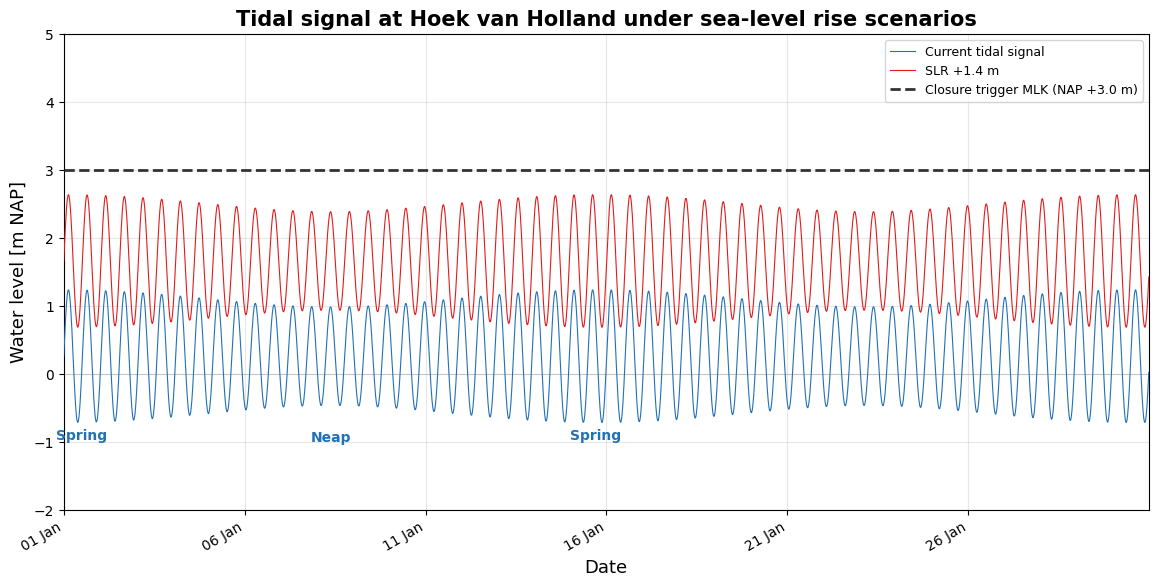


══ Tidal parameters Hoek van Holland ══
  M2 amplitude:  0.85 m  (periode: 12.42 hr)
  S2 amplitude:  0.12 m  (periode: 12.00 hr)
  Offset (a₀):   0.26 m NAP
  Spring HW:    ~+1.24 m NAP
  Spring LW:    ~-0.72 m NAP
  Neap HW:      ~+0.99 m NAP
  Neap LW:      ~-0.47 m NAP
  Tide:          1.95 m (spring)
                 1.45 m (neap)


In [10]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta

T_M2 = T_M2_s
T_S2 = T_S2_s

# Sea-level rise scenarios
SLR_design = 1.4   

# Closure trigger 
closure_trigger = 3.00  

# ─── Time: 30 days (~2 spring-neap cycli) ───
t_start = datetime(2025, 1, 1)
dt_sec  = 600  # 10-min resolution
n_days  = 30
t_total = n_days * 24 * 3600
t_sec   = np.arange(0, t_total, dt_sec)
t_dates = [t_start + timedelta(seconds=float(s)) for s in t_sec]

# ─── Tidal signal (M2 + S2 superposition) ───
def tidal_signal(t, slr=0.0):
    return a_0 + slr + a_M2 * np.sin(omega_M2 * t) \
                     + a_S2 * np.sin(omega_S2 * t)

h_current = tidal_signal(t_sec, slr=0.0)
h_design  = tidal_signal(t_sec, slr=SLR_design)

# ─── Plot ───
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(t_dates, h_current, color='#2171b5', linewidth=0.8,
        label='Current tidal signal', zorder=3)
ax.plot(t_dates, h_design, color='#e41a1c', linewidth=0.8,
        label=f'SLR +{SLR_design} m ', zorder=3)

# Closure trigger
ax.axhline(y=closure_trigger, color='#333333', linewidth=2,
           linestyle='--', label=f'Closure trigger MLK (NAP +{closure_trigger} m)',
           zorder=4)

# NAP reference
ax.axhline(y=0, color='grey', linewidth=0.5, linestyle='-', alpha=0.5)

# Spring / neap annotations
ax.annotate('Spring', xy=(t_dates[int(0.5*24*6)], max(h_current[:int(2*24*6)])),
            xytext=(0, -110),              
            textcoords='offset points',
            fontsize=10, ha='center', va='bottom', color='#2171b5',
            fontweight='bold')
ax.annotate('Neap', xy=(t_dates[int(7.4*24*6)], max(h_current[int(6.5*24*6):int(8.5*24*6)])),
            xytext=(0, -100),             
            textcoords='offset points',
            fontsize=10, ha='center', va='bottom', color='#2171b5',
            fontweight='bold')
ax.annotate('Spring',
            xy=(t_dates[int(14.7*24*6)], max(h_current[int(13.5*24*6):int(16*24*6)])),
            xytext=(0, -110),             
            textcoords='offset points',
            fontsize=10, ha='center', va='bottom', color='#2171b5',
            fontweight='bold')

# Formatting
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Water level [m NAP]', fontsize=13)
ax.set_title('Tidal signal at Hoek van Holland under sea-level rise scenarios',
             fontsize=15, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, frameon=True)
ax.grid(True, alpha=0.3)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
fig.autofmt_xdate()

ax.set_ylim(-2.0, 5.0)
ax.set_xlim(t_dates[0], t_dates[-1])

fig.savefig('tidal_signal_slr.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()

# ─── Print summary───
print(f"\n══ Tidal parameters Hoek van Holland ══")
print(f"  M2 amplitude:  {a_M2:.2f} m  (periode: {T_M2/3600:.2f} hr)")
print(f"  S2 amplitude:  {a_S2:.2f} m  (periode: {T_S2/3600:.2f} hr)")
print(f"  Offset (a₀):   {a_0:.2f} m NAP")
print(f"  Spring HW:    ~{a_0 + a_M2 + a_S2:+.2f} m NAP")
print(f"  Spring LW:    ~{a_0 - a_M2 - a_S2:+.2f} m NAP")
print(f"  Neap HW:      ~{a_0 + a_M2 - a_S2:+.2f} m NAP")
print(f"  Neap LW:      ~{a_0 - a_M2 + a_S2:+.2f} m NAP")
print(f"  Tide:          {2*(a_M2+a_S2):.2f} m (spring)")
print(f"                 {2*(a_M2-a_S2):.2f} m (neap)")